# Breast Cancer Diagnosis Analysis using ML

Random forests are considered a top choice when choosing a ML model for real-world data such as medical data. It is commonly believed they provide robustness as data transformations aren't necessary.

This notebook aims to analyze this belief by comparing two different ML models against random forest to study which performs the best at classifying cancer cells as malignant or benign for breast cancer, when data transformations are kept minimal. The findings of this study can have huge real-world implications as it can help doctors and others in the medical field to better know how to develop models to care for patients.

# Set up: Add packages and retrieve data

In [282]:
# importing required packages
import pandas as pd # will be used throughout the project
import matplotlib as plt # will be used in data exploration stage
import numpy as np # will be used in data exploration stage

In [284]:
# importing required scikit-learn packages for machine learning
from sklearn.ensemble import RandomForestClassifier # used to access random forest ML method
from sklearn.model_selection import train_test_split # used to set training and testing paramters for model
from sklearn.metrics import accuracy_score, classification_report # used to check and understand results of project

In [286]:
# retrieve data from saved csv file
data = pd.read_csv("data.csv")

read data, which was downloaded from https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?resource=download

In [289]:
# print data 
print(data)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

drop unneccessary column

In [292]:
data = data.drop('Unnamed: 32', axis=1)

In [294]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [296]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [298]:
data.describe

<bound method NDFrame.describe of            id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181

# Data Exploration

In [301]:
data["diagnosis"] = data["diagnosis"].map({'B': 0, 'M': 1})

In [303]:
benign = data[data["diagnosis"] == 0]
malignant = data[data["diagnosis"] == 1]

In [305]:
print(benign)

           id  diagnosis  radius_mean  texture_mean  perimeter_mean  \
19    8510426          0       13.540         14.36           87.46   
20    8510653          0       13.080         15.71           85.63   
21    8510824          0        9.504         12.44           60.34   
37     854941          0       13.030         18.42           82.61   
46   85713702          0        8.196         16.84           51.71   
..        ...        ...          ...           ...             ...   
558    925277          0       14.590         22.68           96.39   
559    925291          0       11.510         23.93           74.52   
560    925292          0       14.050         27.15           91.38   
561    925311          0       11.200         29.37           70.67   
568     92751          0        7.760         24.54           47.92   

     area_mean  smoothness_mean  compactness_mean  concavity_mean  \
19       566.3          0.09779           0.08129         0.06664   
20       

In [307]:
print(malignant)

           id  diagnosis  radius_mean  texture_mean  perimeter_mean  \
0      842302          1        17.99         10.38          122.80   
1      842517          1        20.57         17.77          132.90   
2    84300903          1        19.69         21.25          130.00   
3    84348301          1        11.42         20.38           77.58   
4    84358402          1        20.29         14.34          135.10   
..        ...        ...          ...           ...             ...   
563    926125          1        20.92         25.09          143.00   
564    926424          1        21.56         22.39          142.00   
565    926682          1        20.13         28.25          131.20   
566    926954          1        16.60         28.08          108.30   
567    927241          1        20.60         29.33          140.10   

     area_mean  smoothness_mean  compactness_mean  concavity_mean  \
0       1001.0          0.11840           0.27760         0.30010   
1       1

In [309]:
print("Benign description:")
benign.describe()

Benign description:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,3.570000e+02,357.0,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,...,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000
mean,2.654382e+07,0.0,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
std,1.167397e+08,0.0,1.780512,3.995125,11.807438,134.287118,0.013446,0.033750,0.043442,0.015909,...,1.981368,5.493955,13.527091,163.601424,0.020013,0.092180,0.140368,0.035797,0.041745,0.013804
min,8.913000e+03,0.0,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210
25%,8.746620e+05,0.0,11.080000,15.150000,70.870000,378.200000,0.083060,0.055620,0.020310,0.015020,...,12.080000,19.580000,78.270000,447.100000,0.110400,0.112000,0.077080,0.051040,0.240600,0.070090
50%,9.089160e+05,0.0,12.200000,17.390000,78.180000,458.400000,0.090760,0.075290,0.037090,0.023440,...,13.350000,22.820000,86.920000,547.400000,0.125400,0.169800,0.141200,0.074310,0.268700,0.077120
75%,8.812816e+06,0.0,13.370000,19.760000,86.100000,551.100000,0.100700,0.097550,0.059990,0.032510,...,14.800000,26.510000,96.590000,670.000000,0.137600,0.230200,0.221600,0.097490,0.298300,0.085410
max,9.113205e+08,0.0,17.850000,33.810000,114.600000,992.100000,0.163400,0.223900,0.410800,0.085340,...,19.820000,41.780000,127.100000,1210.000000,0.200600,0.584900,1.252000,0.175000,0.422800,0.148600


In [311]:
print("Malignant description:")
malignant.describe()

Malignant description:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,2.120000e+02,212.0,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,...,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,3.681805e+07,1.0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
std,1.378965e+08,0.0,3.203971,3.779470,21.854653,367.937978,0.012608,0.053987,0.075019,0.034374,...,4.283569,5.434804,29.457055,597.967743,0.021870,0.170372,0.181507,0.046308,0.074685,0.021553
min,8.670000e+03,1.0,10.950000,10.380000,71.900000,361.600000,0.073710,0.046050,0.023980,0.020310,...,12.840000,16.670000,85.100000,508.100000,0.088220,0.051310,0.023980,0.028990,0.156500,0.055040
25%,8.613450e+05,1.0,15.075000,19.327500,98.745000,705.300000,0.094010,0.109600,0.109525,0.064620,...,17.730000,25.782500,119.325000,970.300000,0.130475,0.244475,0.326425,0.152750,0.276500,0.076302
50%,8.953665e+05,1.0,17.325000,21.460000,114.200000,932.000000,0.102200,0.132350,0.151350,0.086280,...,20.590000,28.945000,138.000000,1303.000000,0.143450,0.356350,0.404900,0.182000,0.310300,0.087600
75%,8.911290e+06,1.0,19.590000,23.765000,129.925000,1203.750000,0.110925,0.172400,0.203050,0.103175,...,23.807500,32.690000,159.800000,1712.750000,0.155975,0.447850,0.556175,0.210675,0.359225,0.102625
max,9.112962e+08,1.0,28.110000,39.280000,188.500000,2501.000000,0.144700,0.345400,0.426800,0.201200,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.170000,0.291000,0.663800,0.207500


Just by analyzing the two dataframes, it can be inferred that the cell nuclei of malignant patients have higher measurements than those who are benign. In some cases it's only a small difference, in others it's a large difference. While this doesn't play a role in predicting the diagnosis, it gives important background information and illustrates how the two cell types differ.

In [314]:
data.corr()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,...,0.082405,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.012968,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661


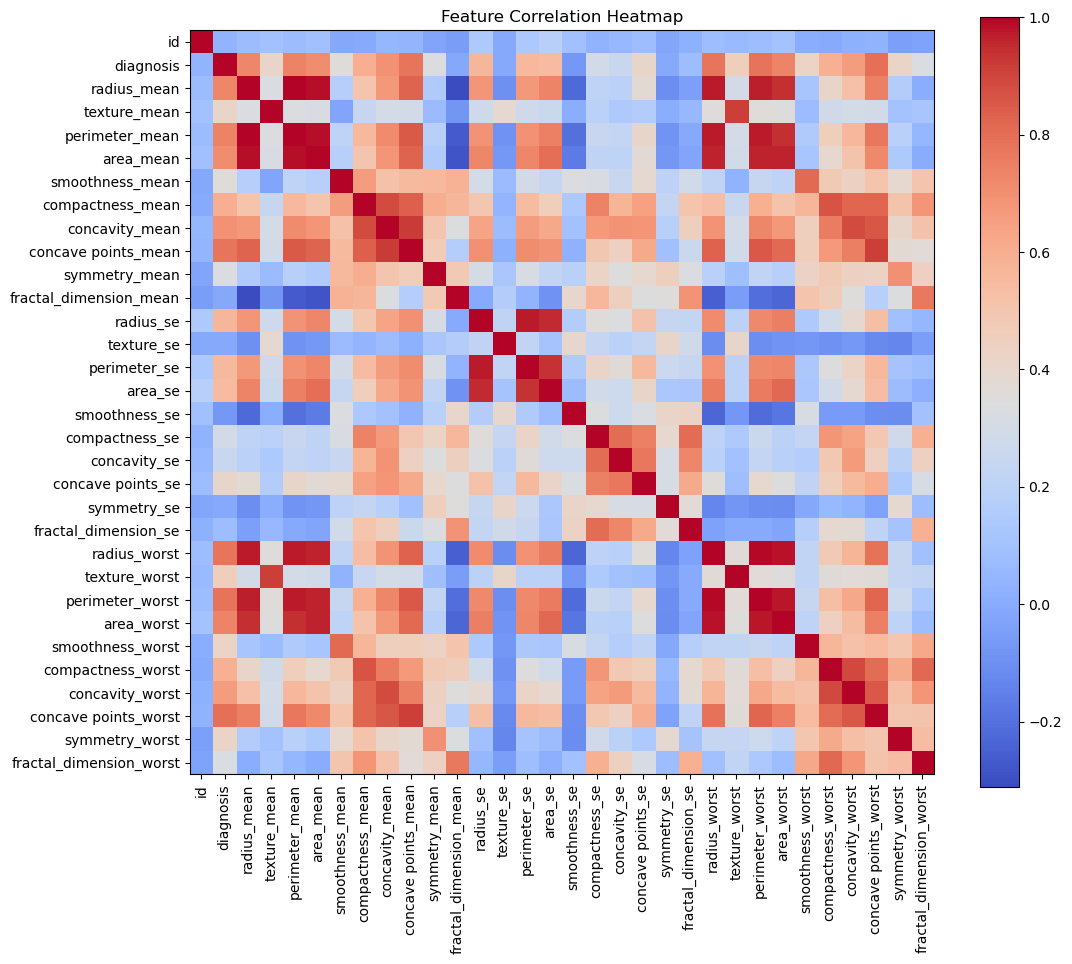

In [316]:
import matplotlib.pyplot as plt

correlations = data.corr()

plt.figure(figsize=(12, 10))
plt.imshow(correlations, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlations.columns)), correlations.columns, rotation=90)
plt.yticks(range(len(correlations.columns)), correlations.columns)

plt.title("Feature Correlation Heatmap")
plt.show()

Previous two cells show there aren't too many features that are highly correlated, as we're not performing data transformations, there is no change, but this helps to understand the data better as well as why the upcoming models perform the way they will.

In [319]:
print("There are", len(data['id'].unique().tolist()), "unique values out of", len(data), "rows")

There are 569 unique values out of 569 rows


Each patient id is unique, meaning if included in our training set, the models can easily use this feature to cheat, thus leading to better performance. However, we don't want them to cheat as it will poorly prepare the models for real-world applications, so this feature needs to be dropped. (It also means there aren't duplicated rows in the dataset)

# Setting Parameters

In [323]:
from sklearn.model_selection import train_test_split

set the x (feature) and y (labeled) value

the feature values are the data catergories that will be used to determine our diagnosis

the labeled value will be our end result which is the actual diagnosis of M (malignant) or B (benign)

In [326]:
# features are every column but 'diagnosis'; need to drop patient id as it'll help model "cheat"
X = data.drop(["diagnosis", "id"], axis=1)

# label is the diagnosis column
y = data['diagnosis']

split data into training and testing data

now it's time to train our models

In [330]:
# 70% of data will be used to train, 30% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest 

In [333]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

create random forest classifier objects

since random forest relies on multiple decision trees, lets use GridSearch to find the best possible combinations of parameters

In [337]:
rf_cls = RandomForestClassifier(random_state=0)

params = {
    'n_estimators': [50, 100, 250, 500],
    'max_depth': [None, 1, 2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced'],
    'max_features': [None, 'sqrt', 'log2']
}

rf_grid_search = GridSearchCV(estimator=rf_cls, param_grid=params, cv=5, scoring='recall')
rf_grid_search.fit(X_train, y_train)

print("Best Parameters:", rf_grid_search.best_params_)
print("Best Score:", rf_grid_search.best_score_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
Best Score: 0.9395402298850575


              precision    recall  f1-score   support

           0       0.97      0.97      0.97       108
           1       0.95      0.95      0.95        63

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



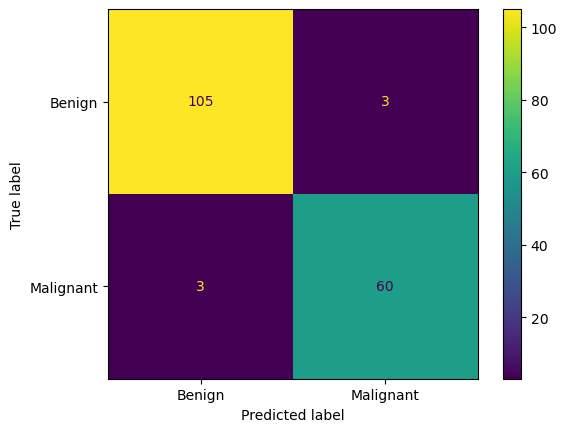

In [339]:
import matplotlib.pyplot as plt

rf_y_pred = rf_grid_search.predict(X_test)

print(classification_report(y_test, rf_y_pred))

rf_cm = confusion_matrix(y_test, rf_y_pred)

rf_display = ConfusionMatrixDisplay(rf_cm, display_labels=['Benign', 'Malignant'])
rf_display.plot(cmap='viridis')
plt.show()

In [345]:
from sklearn.metrics import recall_score, precision_score, f1_score

rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print("Precision::", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Precision:: 0.9523809523809523
Recall: 0.9523809523809523
F1: 0.9523809523809523


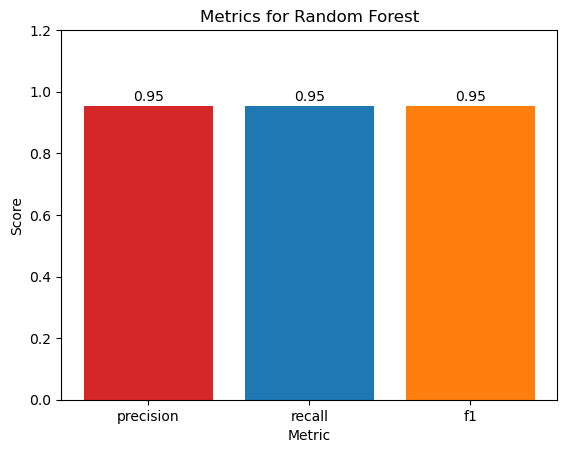

In [347]:
def rf_metrics():
    fig, ax = plt.subplots()
    
    metrics = [rf_precision, rf_recall, rf_f1]
    labels = ['precision', 'recall', 'f1']
    colors = ['tab:red', 'tab:blue', 'tab:orange']
    
    rf_bars = ax.bar(labels, metrics, color=colors)
    
    ax.bar_label(rf_bars, padding=2, fmt='%.2f')
    ax.set_title("Metrics for Random Forest")
    ax.set_ylabel("Score")
    ax.set_xlabel("Metric")
    ax.set_ylim(0, 1.2)
    
    plt.show()

rf_metrics()

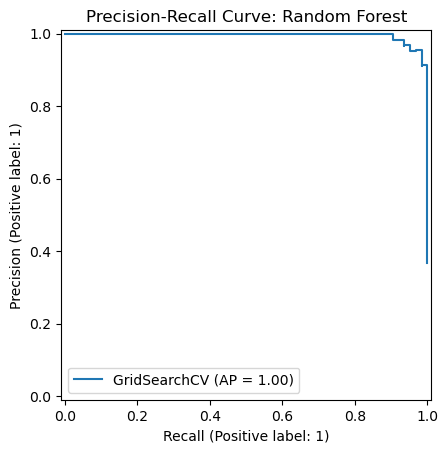

In [349]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Generate a precision-recall curve
rf_pr = PrecisionRecallDisplay.from_estimator(rf_grid_search, X_test, y_test)

plt.title("Precision-Recall Curve: Random Forest")
plt.show()

The model is great at predicting patients' diagnosis

# Support Vectors

In [353]:
from sklearn import svm

In [355]:
svc_cls = svm.SVC(random_state=0)

params = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

svc_grid_search = GridSearchCV(estimator=svc_cls, param_grid=params, cv=5, scoring='recall')
svc_grid_search.fit(X_train, y_train)

print("Best Parameters:", svc_grid_search.best_params_)
print("Best Score:", svc_grid_search.best_score_)

Best Parameters: {'C': 10.0, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.9595402298850575


              precision    recall  f1-score   support

           0       0.98      0.94      0.96       108
           1       0.91      0.97      0.94        63

    accuracy                           0.95       171
   macro avg       0.95      0.96      0.95       171
weighted avg       0.95      0.95      0.95       171



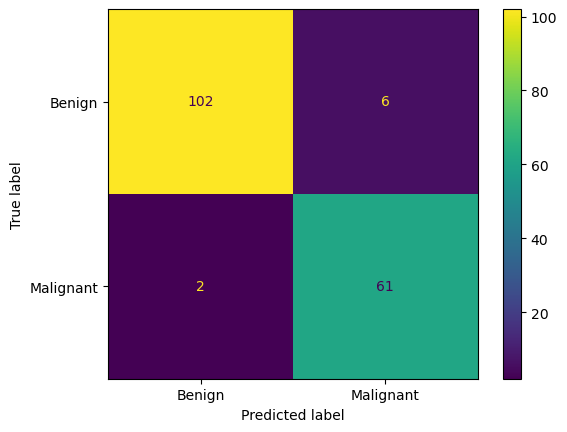

In [361]:
svc_y_pred = svc_grid_search.predict(X_test)

print(classification_report(y_test, svc_y_pred))

svc_cm = confusion_matrix(y_test, svc_y_pred)

svc_display = ConfusionMatrixDisplay(svc_cm, display_labels=['Benign', 'Malignant'])
svc_display.plot(cmap='viridis')
plt.show()

In [363]:
svc_precision = precision_score(y_test, svc_y_pred)
svc_recall = recall_score(y_test, svc_y_pred)
svc_f1 = f1_score(y_test, svc_y_pred)

print("Precision::", svc_precision)
print("Recall:", svc_recall)
print("F1:", svc_f1)

Precision:: 0.9104477611940298
Recall: 0.9682539682539683
F1: 0.9384615384615385


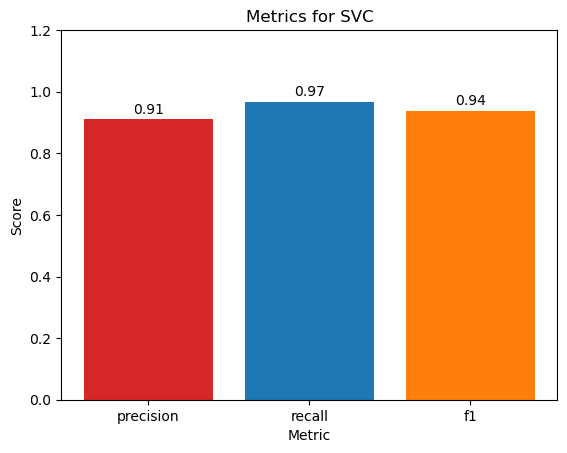

In [365]:
def svc_metrics():
    fig, ax = plt.subplots()
    
    metrics = [svc_precision, svc_recall, svc_f1]
    labels = ['precision', 'recall', 'f1']
    colors = ['tab:red', 'tab:blue', 'tab:orange']
    
    svc_bars = ax.bar(labels, metrics, color=colors)

    ax.bar_label(svc_bars, padding=2, fmt='%.2f')
    ax.set_title("Metrics for SVC")
    ax.set_ylabel("Score")
    ax.set_xlabel("Metric")
    ax.set_ylim(0, 1.2)
    
    plt.show()

svc_metrics()

In [257]:
met

NameError: name 'met' is not defined

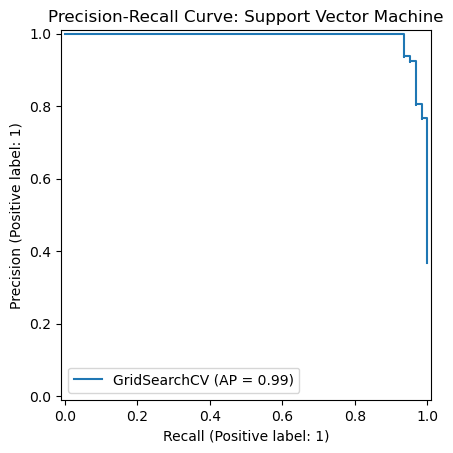

In [367]:
svc_pr = PrecisionRecallDisplay.from_estimator(svc_grid_search, X_test, y_test)

plt.title("Precision-Recall Curve: Support Vector Machine")
plt.show()

# Naive Bayes

In [370]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score

Typically don't need grid search for Gaussian Naive Bayes

In [373]:
gnb_cls = GaussianNB()

gnb_cls.fit(X_train, y_train)

GaussianNB()

In [375]:
gnb_y_pred = gnb_cls.predict(X_test)

print("Score:", recall_score(y_test, gnb_y_pred))

Score: 0.9047619047619048


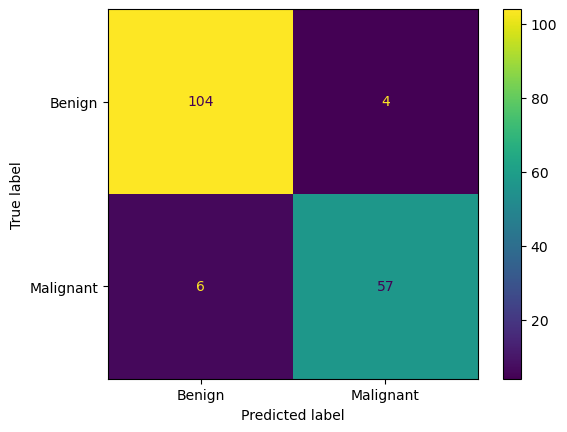

In [377]:
gnb_cm = confusion_matrix(y_test, gnb_y_pred)

gnb_display = ConfusionMatrixDisplay(gnb_cm, display_labels=['Benign', 'Malignant'])
gnb_display.plot(cmap='viridis')
plt.show()

In [379]:
gnb_precision = precision_score(y_test, gnb_y_pred)
gnb_recall = recall_score(y_test, gnb_y_pred)
gnb_f1 = f1_score(y_test, gnb_y_pred)

print("Precision::", gnb_precision)
print("Recall:", gnb_recall)
print("F1:", gnb_f1)

Precision:: 0.9344262295081968
Recall: 0.9047619047619048
F1: 0.9193548387096774


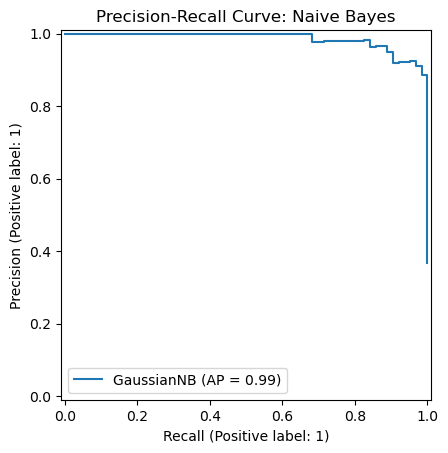

In [381]:
gnb_pr = PrecisionRecallDisplay.from_estimator(gnb_cls, X_test, y_test)

plt.title("Precision-Recall Curve: Naive Bayes")
plt.show()

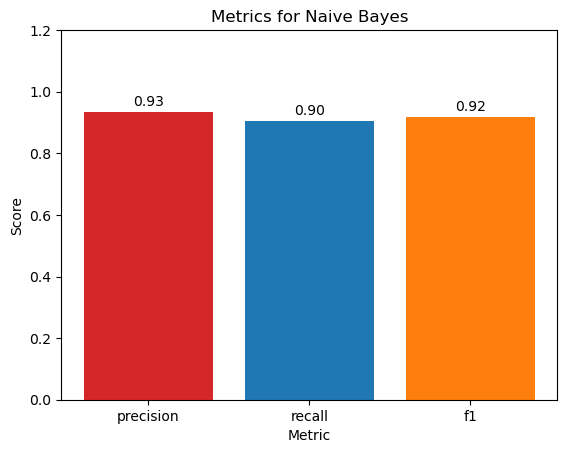

In [383]:
def gnb_metrics():
    fig, ax = plt.subplots()
    
    metrics = [gnb_precision, gnb_recall, gnb_f1]
    labels = ['precision', 'recall', 'f1']
    colors = ['tab:red', 'tab:blue', 'tab:orange']
    
    gnb_bars = ax.bar(labels, metrics, color=colors)

    ax.bar_label(gnb_bars, padding=2, fmt='%.2f')
    ax.set_title("Metrics for Naive Bayes")
    ax.set_ylabel("Score")
    ax.set_xlabel("Metric")
    ax.set_ylim(0, 1.2)
    
    plt.show()

gnb_metrics()

# Results

From the high recall scores as well the PR AUC, it is clear that all three models perform well when no data transformations were performed. As we removed features that would help the models "cheat", this indicates the dataset was likely already prepared for ML models, even though there is some difference in ranges across features.

Nonetheless, random forests still performed slightly better than the other two models. While the two models have AP scores of roughly 0.99, and random forest has a score of approximately 1.00, the confusion matrices and bar charts show why the random forest are supreme, especially in the medical setting.

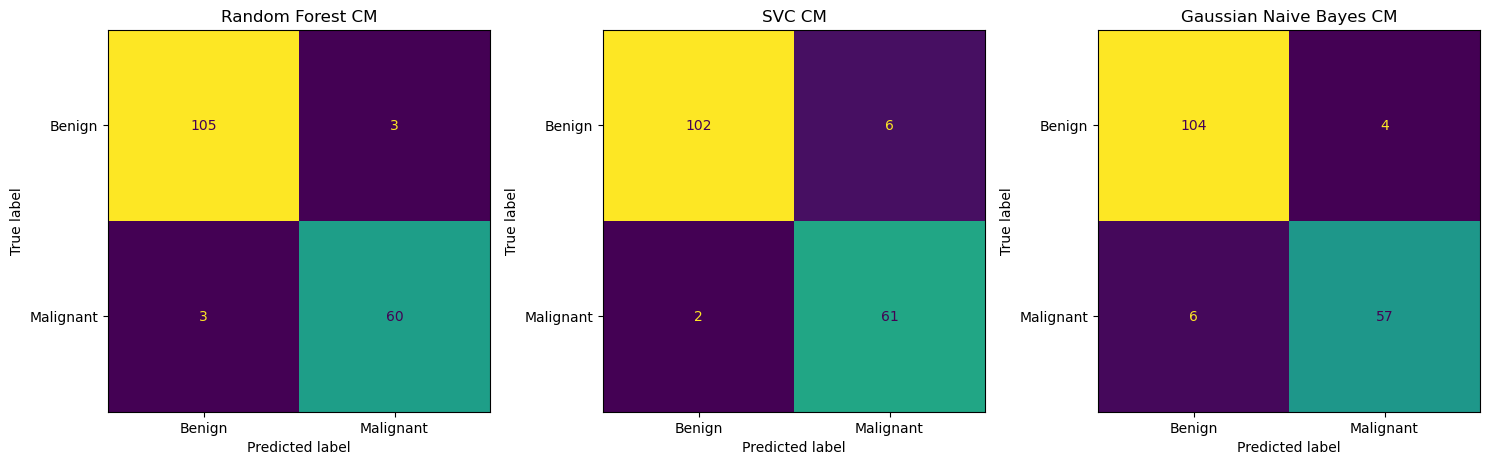

In [386]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

rf_display.plot(ax=ax[0], colorbar=False)
ax[0].set_title('Random Forest CM')

svc_display.plot(ax=ax[1], colorbar=False)
ax[1].set_title('SVC CM')

gnb_display.plot(ax=ax[2], colorbar=False)
ax[2].set_title('Gaussian Naive Bayes CM')

plt.tight_layout()
plt.show()


From these matrices we can see that each model produces similar values for each of true and false label (TP, FP, TN, and FN). The gol in medical data is to lower FNs and SVC has the fewest with 2, but random forest only has 3. Random forest managed to capture the most TNs with 105, while also having the least FPs of 3. This captures why the model is the most useful as typically FPs increase as FNs decrease due to precision-recall trade-offs. This indicates that the model is performed better overall and this can be seen when you compare each model's bar charts.

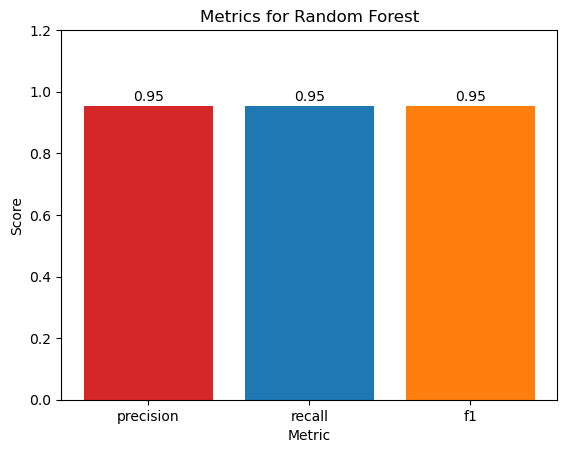

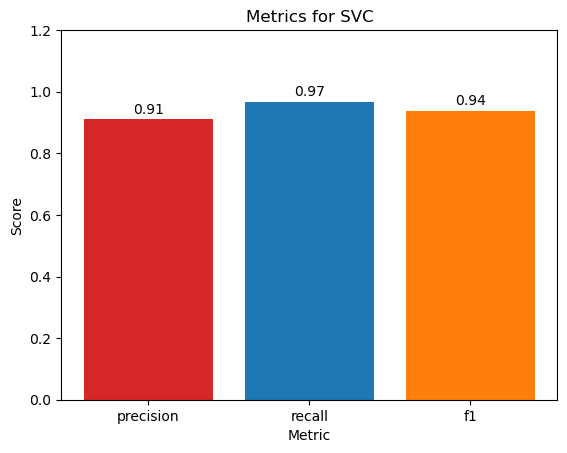

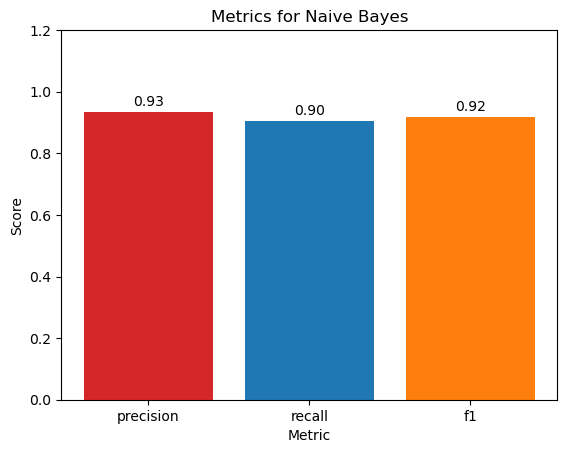

In [388]:
rf_metrics()
svc_metrics()
gnb_metrics()

From these charts we can see the random forest outperforming the SVC and Naive Bayes. The SVC does score the highest recall score with 0.97, but random forest is right behind it with 0.095, which is still impressive. However, what makes radnom forest stand out is that it achieved a high recall, while also achieving the highest precision and F1 scores of all three models. This is impressive as with precision-recall trade-offs, preicision tends to decline as recall increases, and vice versa. This can be seen as the SVC has a recall of 0.97 and precision of 0.91, while the Niave Bayes has 0.93 precision and 0.9 recall. The random froest achieves a score of 0.95 in both. Additionally, its F1 score of 0.95 beats the F1 scores of the other two. High performance in each metric make the model the best overall.

This study confirms the common belief that random froests can provide robustness and high performance when data transformations are kept minimal. However, it does show SVC and Naive Bayes can still perform impressively. More research and testing will need to be done before this can be confirmed as it is possible the dataset was already properly prepared for ML models, leading to high performances across all models. This project could be redone with a separate dataset to confirm results.

Based of this notebook, medical professionals should still utilize random forests when developing models to analyze patient data and determine how to care for them. This powerful method will ensure doctors don't have to go through the mundane task of transforming data as real-world data can be large and having to transform it can take away time from professionals, when they could be treating patients.